<a href="https://colab.research.google.com/github/DN575MGPU/-/blob/lab_alg_2/%D0%BB%D0%B0%D0%B1%D0%B0_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D1%8B_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

5 верш: (1,2), (1,3), (1,4), (4,5)
Дерево - элементы для постороения: {31, 22, 37, 20, 25, 33, 40}
Дерево - найти/ удалить: Найти: 33, Уд.: 22
Куча - массив для Heap Sort: [31, 22, 37, 20, 25, 33, 40]

Матрица смежности:
[0, 1, 1, 1, 0]
[1, 0, 0, 0, 0]
[1, 0, 0, 0, 0]
[1, 0, 0, 0, 1]
[0, 0, 0, 1, 0]

Матрица инцидентности (5x4):
[1, 1, 1, 0]
[1, 0, 0, 0]
[0, 1, 0, 0]
[0, 0, 1, 1]
[0, 0, 0, 1]

Поиск компонента связности:
[[1], [2], [3], [4], [5]]

Бинарное дерево поиска (BST)
Элементы вставлены: [31, 22, 37, 20, 25, 33, 40]


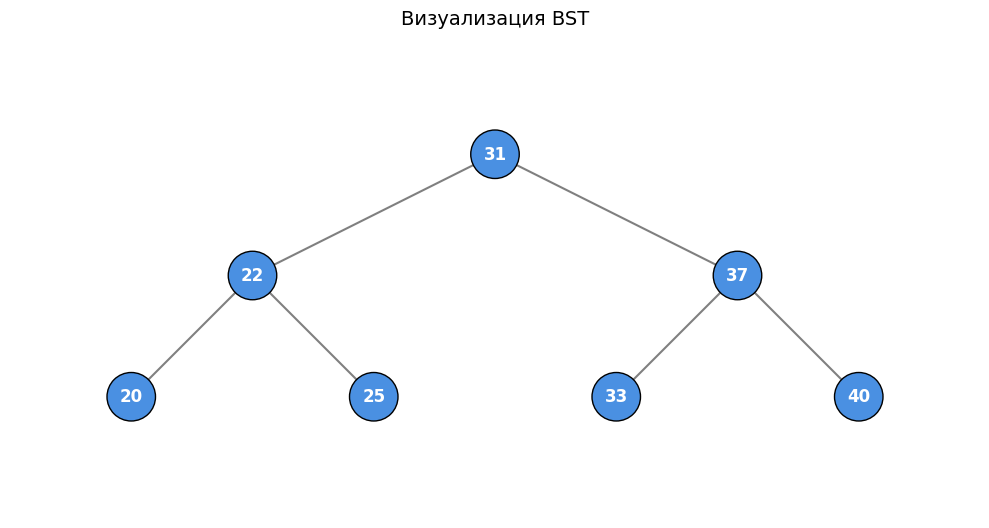

Поиск 33: Найден
Узел 22 удален.



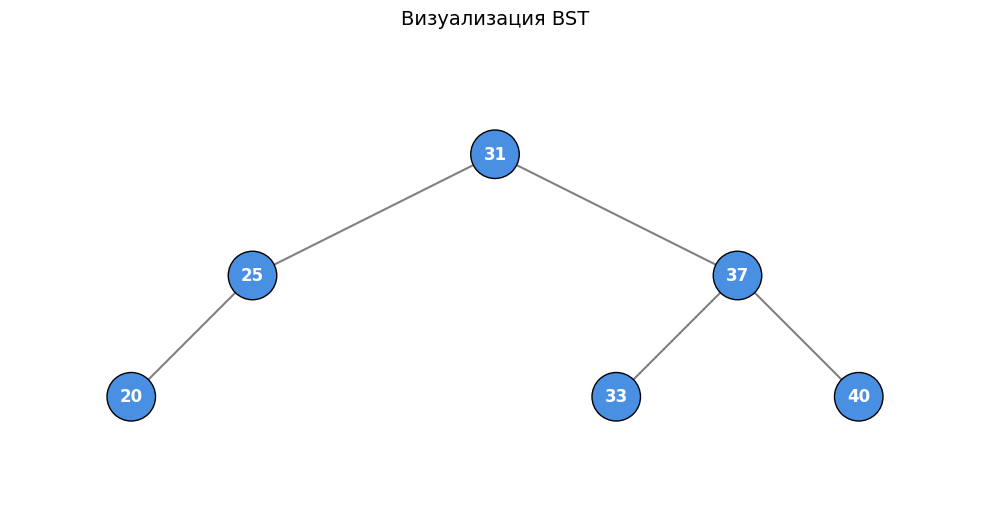


Сортировка кучей (Heap Sort)
Исходный массив: [31, 22, 37, 20, 25, 33, 40]
Отсортированный массив: [20, 22, 25, 31, 33, 37, 40]


In [5]:
# Задание task 02_18
# Дано: 5 верш: (1,2), (1,3), (1,4), (4,5)
# Дерево - элементы для постороения: {31, 22, 37, 20, 25, 33, 40}
# Найти: 33, Уд.: 22
# Массив для Heap Sort: [31, 22, 37, 20, 25, 33, 40]
# Выполнила Новожилкина Дарья
# Группа: ЦИБ-251

# ============================================
# БИБЛИОТЕКИ
# ============================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# Генерация матриц смежности и инцидентности

def generate_matrix(n, edges):
  # Матрица смежности
    A = [[0] * n for _ in range(n)]
  # Матрица инцидентности
    m = len(edges)
    inc = [[0] * m for _ in range(n)]
    for idx, (i, j) in enumerate(edges):
      # Приводит к 0-индексации (вершины с 1 переводит в 0)
        u = i - 1
        v = j - 1
      # Заполняет матрицу смежности для неориентированного графа
        A[u][v] = 1
        A[v][u] = 1

      # Заполняет матрицу инцидентности
      # Для неориентированного графа: 1 — инцидентна, 0 — нет
        inc[u][idx] = 1
        inc[v][idx] = 1

    return A, inc

n = 5
edges = [(1,2), (1,3), (1,4), (4,5)]

A, inc = generate_matrix(n, edges)

# Поиск компонента связности по матрице смежности

def components_from_adj_matrix(A):

    n = len(A)
    visited = [False] * n
    components = []

    def bfs(start):
        queue = [start]
        visited[start] = True
        comp = []
        while queue:
            v = queue.pop(0)
            comp.append(v + 1)  # возвращает в 1-индексацию
            for i in range(n):
                if A[v][u] and not visited[u]:
                    visited[u] = True
                    queue.append(u)
        return comp

    for u in range(n):
        if not visited[u]:
            components.append(bfs(u))

    return components


result = components_from_adj_matrix(A)



# Бинарное дерево поиска (BST)

class Node:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None

class BST:
    def __init__(self):
        self.root = None

    def insert(self, key):
        """Вставка нового элемента в дерево."""
        if self.root is None:
            self.root = Node(key)
        else:
            self._insert_recursive(self.root, key)

    def _insert_recursive(self, node, key):
        if key < node.key:
            if node.left is None:
                node.left = Node(key)
            else:
                self._insert_recursive(node.left, key)
        elif key > node.key:
            if node.right is None:
                node.right = Node(key)
            else:
                self._insert_recursive(node.right, key)

    def search(self, key):
        """Поиск элемента. Возвращает узел или None."""
        return self._search_recursive(self.root, key)

    def _search_recursive(self, node, key):
        if node is None or node.key == key:
            return node
        if key < node.key:
            return self._search_recursive(node.left, key)
        return self._search_recursive(node.right, key)

    def delete(self, key):
        """Удаление элемента из дерева."""
        self.root = self._delete_recursive(self.root, key)

    def _delete_recursive(self, node, key):
        if node is None:
            return node

        if key < node.key:
            node.left = self._delete_recursive(node.left, key)
        elif key > node.key:
            node.right = self._delete_recursive(node.right, key)
        else:
            # Случай 1: нет левого потомка
            if node.left is None:
                return node.right
            # Случай 2: нет правого потомка
            elif node.right is None:
                return node.left

            # Случай 3: два потомка -> заменяет на наименьший элемент правого поддерева
            temp = self._min_value_node(node.right)
            node.key = temp.key
            node.right = self._delete_recursive(node.right, temp.key)
        return node

    def _min_value_node(self, node):
        current = node
        while current.left is not None:
            current = current.left
        return current



# Визуализация дерева (matplotlib)

def visualize_bst(bst):
    """Отрисовка BST с использованием matplotlib."""
    if bst.root is None:
        print("Дерево пусто.")
        return

    pos = {}
    def assign_positions(node, x=0, y=0, dx=4, dy=2):
        """Рекурсивное назначение координат узлам."""
        if node is None:
            return
        pos[node.key] = (x, y)
        assign_positions(node.left,  x - dx, y - dy, dx / 2, dy)
        assign_positions(node.right, x + dx, y - dy, dx / 2, dy)

    assign_positions(bst.root)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_aspect('equal')

    # Рёбра
    def draw_edges(node):
        if node is None:
            return
        if node.left:
            x1, y1 = pos[node.key]
            x2, y2 = pos[node.left.key]
            ax.plot([x1, x2], [y1, y2], color='gray', zorder=1, linewidth=1.5)
            draw_edges(node.left)
        if node.right:
            x1, y1 = pos[node.key]
            x2, y2 = pos[node.right.key]
            ax.plot([x1, x2], [y1, y2], color='gray', zorder=1, linewidth=1.5)
            draw_edges(node.right)

    draw_edges(bst.root)

    # Узлы и подписи
    for key, (x, y) in pos.items():
        circle = mpatches.Circle((x, y), radius=0.4, facecolor='#4A90E2', edgecolor='black', zorder=2)
        ax.add_patch(circle)
        ax.text(x, y, str(key), ha='center', va='center', fontsize=12, fontweight='bold', color='white', zorder=3)

    # Настройка осей и отображение
    xs = [x for x, _ in pos.values()]
    ys = [y for _, y in pos.values()]
    ax.set_xlim(min(xs) - 2, max(xs) + 2)
    ax.set_ylim(min(ys) - 2, max(ys) + 2)
    ax.axis('off')
    plt.title("Визуализация BST", fontsize=14)
    plt.tight_layout()
    plt.show()

# Сортировка кучей (Heap Sort)

def heapify(arr, n, i):
    """Превращает поддерево в кучу (max-heap)."""
    largest = i
    left = 2 * i + 1
    right = 2 * i + 2

    if left < n and arr[left] > arr[largest]:
        largest = left
    if right < n and arr[right] > arr[largest]:
        largest = right

    if largest != i:
        arr[i], arr[largest] = arr[largest], arr[i]  # swap
        heapify(arr, n, largest)

def heap_sort(arr):
    """Основной алгоритм Heap Sort."""
    n = len(arr)
    # Построение max-кучи
    for i in range(n // 2 - 1, -1, -1):
        heapify(arr, n, i)
    # Извлечение элементов по одному
    for i in range(n - 1, 0, -1):
        arr[i], arr[0] = arr[0], arr[i]  # swap
        heapify(arr, i, 0)
    return arr



# Запуск

if __name__ == "__main__":
    print("Матрица смежности:")
    for row in A:
        print(row)
    print()

    print("Матрица инцидентности (5x4):")
    for row in inc:
        print(row)
    print()

    print('Поиск компонента связности:')
    print(result)
    print()

    print("Бинарное дерево поиска (BST)")
    elements = [31, 22, 37, 20, 25, 33, 40]
    bst = BST()

    for e in elements:
        bst.insert(e)
    print(f"Элементы вставлены: {elements}")
    visualize_bst(bst)
    # Поиск
    found = bst.search(33)
    print(f"Поиск 33: {'Найден' if found else 'Не найден'}")

    # Удаление
    bst.delete(22)
    print("Узел 22 удален.\n")

    # Визуализация
    visualize_bst(bst)
    print()

    print("Сортировка кучей (Heap Sort)")
    arr = [31, 22, 37, 20, 25, 33, 40]
    print(f"Исходный массив: {arr}")
    heap_sort(arr)
    print(f"Отсортированный массив: {arr}")

